# Parallel Transport SPDNet

After careful observation of SPDNet direct LogEig layer on SPD matrices on S++ latent space, showing that the norm of the tangent vectors were much higher than the tangent space mapping (that is, that the AIM metric is better than the LERM), this notebook will introduce a SPDMBN before SPDNet's LogEig layer.

This introduction will parallel trnaport the dataset from the estimated Karcher mean to the identity. This way, we can use linear after the LogEig with enriched features, maintaining the distribution.

In [1]:
# Lib
import sys
sys.path.append("/home/rffl/files/ic/utils/")

import torch
import datagen, eegdataset #type: ignore
from spd_learn.models import EEGSPDNet
from torch.utils.data import DataLoader
from torchmetrics.classification import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
import pyriemann as rmn


device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
# Data config
classVec = [i+1 for i in range(10)]
subVec = [i+1 for i in range(10)]

nClass = len(classVec)
nSub = len(subVec)

In [3]:
# Data gen
train_path, test_path = datagen.generatedataset(classVec, subVec, 0.75, False)

Saved ./train.npy shape = (6000, 17, 100)
Saved ./test.npy shape = (2000, 17, 100)


In [4]:
# xDAWN treatment
import pyriemann as rmn
xDAWNfilters = 5
estimator = "lwf"

X_train = np.load(train_path, allow_pickle=True)
X_test = np.load(test_path, allow_pickle=True)

y_train = np.array([])
part = len(X_train) // len(classVec)
for i in range(len(classVec)):
    y_train = np.concatenate([y_train, i * np.ones(part)])

xdawn = rmn.estimation.Xdawn(nfilter=xDAWNfilters, estimator=estimator)
xdawn.fit(X_train, y_train)

X_train = np.einsum('fc,nct->nft', xdawn.filters_, X_train)
X_test  = np.einsum('fc,nct->nft', xdawn.filters_, X_test)

np.save(train_path, X_train )
np.save(test_path, X_test )

In [5]:
# Dataset and Dataloader init
trainDataset = eegdataset.KClassDataset(nClass, "./train.npy")
trainLoader = DataLoader(trainDataset, 40, True, num_workers=4)

testDataset = eegdataset.KClassDataset(nClass, "./test.npy")
testLoader = DataLoader(testDataset, 40, True, num_workers=4)

In [6]:
import time
def regular_train(model, classVec, trainLoader, testLoader, epochs, device):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_hist_loss = []
    test_hist_loss = []

    train_hist_acc = []
    test_hist_acc = []

    begin = time.time()
    print(f"Begin {begin}")
    for epoch in range(epochs):
        train_loss, train_acc = train(model, trainLoader, criterion, optimizer, device)
        test_loss, test_acc = test(model, testLoader, criterion, device)
        train_hist_loss.append(train_loss); train_hist_acc.append(train_acc)
        test_hist_loss.append(test_loss); test_hist_acc.append(test_acc)
        print(f"Epoch {epoch+1}: "
        f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"Test loss {test_loss:.4f}, acc {test_acc:.4f} | "
        f"Time {time.time() - begin} s")

    confmat = ConfusionMatrix(task="multiclass", num_classes=len(classVec))    

    fig, axs = plt.subplots(1,2)
    axs[0].plot(range(epochs), train_hist_loss, label="Train Loss")
    axs[0].plot(range(epochs), test_hist_loss, label="Test Loss")
    axs[0].legend()

    axs[1].plot(range(epochs), train_hist_acc, label="Train Accuracy")
    axs[1].plot(range(epochs), test_hist_acc, label="Test Accuracy")
    axs[1].legend()
    fig.show()

    for X, y in testLoader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        confmat.update(preds.cpu(), y.cpu())

    confmatrix = confmat.compute()
    plot_confusion_matrix(confmatrix, classVec)

def train(model, trainLoader, criterion, optimizer, device):
    torch.cuda.empty_cache()
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in trainLoader:
        X = X.to(device); y = y.to(device)

        optimizer.zero_grad()
        y_hat = model(X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(trainLoader)
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def test(model, testLoader, criterion, device):
    torch.cuda.empty_cache()
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in testLoader:
        X = X.to(device); y = y.to(device)

        y_hat = model(X)
        total_loss += criterion(y_hat, y).item()

        pred = y_hat.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    
    avg_loss = total_loss / len(testLoader)
    acc = correct / total
    return avg_loss, acc

def plot_confusion_matrix(confmatrix, class_names=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(confmatrix, interpolation='nearest')
    plt.title("Confusion Matrix")
    plt.colorbar()

    num_classes = confmatrix.shape[0]

    # Tick labels
    if not class_names:
        class_names = [str(i) for i in range(num_classes)]

    plt.xticks(range(num_classes), class_names, rotation=45)
    plt.yticks(range(num_classes), class_names)

    # Print values inside cells
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, str(confmatrix[i, j].item()),
                     ha="center", va="center", color="white" if confmatrix[i, j] > confmatrix.max()/2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [16]:
from spd_learn.modules import Shrinkage, SPDBatchNormMeanVar

class EEGSPDNetLWF(EEGSPDNet):
    def __init__(self, *args, initShrinkage=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        n_cov = self.n_chans * self.n_filters
        self.shrinkage = Shrinkage(n_chans=n_cov, init_shrinkage=initShrinkage, learnable=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.cov_pool(x)
        x = self.shrinkage(x)
        x = self.spdnet(x)
        x = self.dropout(x)
        x = self.linear(x)
        return x
    
class TSEEGNet(EEGSPDNetLWF):
    def __init__(self, *args, initShrinkage=0.0, spdbn_momentum=0.1, karcher=1, **kwargs):
        super().__init__(*args, initShrinkage=initShrinkage, **kwargs)
        k, n_bimap = self.bimap_sizes
        final_size = int((self.n_chans * self.n_filters) / k ** n_bimap)
        self.spdbn = SPDBatchNormMeanVar(
            num_features=final_size,
            momentum=spdbn_momentum,
            bias_requires_grad=False,  # G-phi fixed to I
            weight_requires_grad=True,
            n_iter=karcher
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.cov_pool(x)
        x = self.shrinkage(x)
        x = self.spdnet[:-1](x)   # everything up to (but not including) LogEig
        x = self.spdbn(x)
        x = self.spdnet[-1](x)    # LogEig
        x = self.dropout(x)
        x = self.linear(x)
        return x

Begin 1783041106.4646142
Epoch 1: Train loss 2.3015, acc 0.1077 | Test loss 2.2930, acc 0.1410 | Time 211.50727224349976 s
Epoch 2: Train loss 2.2967, acc 0.1300 | Test loss 2.2821, acc 0.1965 | Time 420.9522020816803 s
Epoch 3: Train loss 2.2908, acc 0.1427 | Test loss 2.2723, acc 0.2125 | Time 631.8344917297363 s
Epoch 4: Train loss 2.2843, acc 0.1733 | Test loss 2.2652, acc 0.2280 | Time 844.6101987361908 s
Epoch 5: Train loss 2.2805, acc 0.1800 | Test loss 2.2549, acc 0.1975 | Time 1059.370573759079 s
Epoch 6: Train loss 2.2737, acc 0.1998 | Test loss 2.2453, acc 0.2025 | Time 1275.9645233154297 s
Epoch 7: Train loss 2.2662, acc 0.2138 | Test loss 2.2360, acc 0.2370 | Time 1495.1902296543121 s
Epoch 8: Train loss 2.2628, acc 0.2075 | Test loss 2.2276, acc 0.2360 | Time 1713.9148426055908 s
Epoch 9: Train loss 2.2551, acc 0.2177 | Test loss 2.2252, acc 0.2235 | Time 1934.00337433815 s
Epoch 10: Train loss 2.2500, acc 0.2197 | Test loss 2.2141, acc 0.2100 | Time 2155.762720823288 s
E

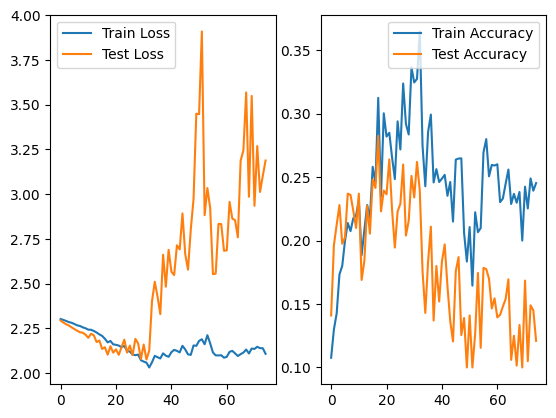

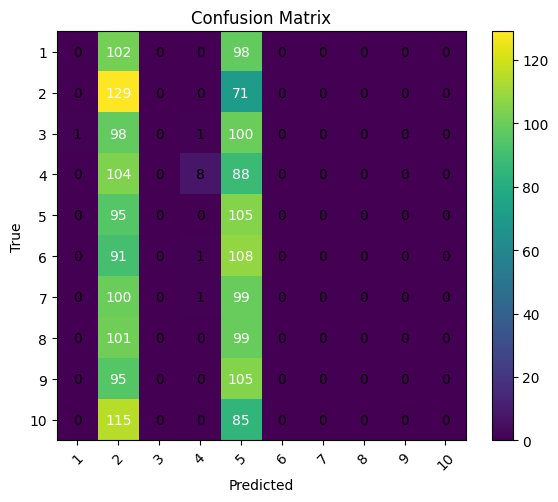

In [ ]:
device = torch.device(device)
model = TSEEGNet(50, 10, n_filters=10, bimap_sizes=(2, 1), filter_time_length = 50, final_layer_drop_prob=0.5, spd_drop_prob=0.25).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)

In [17]:
device = torch.device(device)
model = TSEEGNet(50, 10, n_filters=10, bimap_sizes=(2, 1), filter_time_length = 50, final_layer_drop_prob=0.25, spd_drop_prob=0, karcher=3).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)

Begin 1783071742.7384531


Epoch 1: Train loss 2.2477, acc 0.2125 | Test loss 2.1893, acc 0.2450 | Time 1043.606246471405 s
Epoch 2: Train loss 2.1129, acc 0.3163 | Test loss 2.1088, acc 0.3035 | Time 2049.7303841114044 s
Epoch 3: Train loss 2.0061, acc 0.4045 | Test loss 2.0456, acc 0.3165 | Time 3128.6687228679657 s
Epoch 4: Train loss 1.9120, acc 0.4390 | Test loss 2.0138, acc 0.3250 | Time 4142.743930578232 s
Epoch 5: Train loss 1.8383, acc 0.4773 | Test loss 1.9672, acc 0.3550 | Time 5175.826869249344 s
Epoch 6: Train loss 1.7718, acc 0.5100 | Test loss 1.9553, acc 0.3410 | Time 6263.923346281052 s
Epoch 7: Train loss 1.7062, acc 0.5380 | Test loss 1.9423, acc 0.3375 | Time 7325.907017707825 s
Epoch 8: Train loss 1.6458, acc 0.5617 | Test loss 1.9185, acc 0.3705 | Time 8313.027343511581 s
Epoch 9: Train loss 1.5898, acc 0.5895 | Test loss 1.9081, acc 0.3565 | Time 9389.74113202095 s
Epoch 10: Train loss 1.5443, acc 0.6177 | Test loss 1.8985, acc 0.3560 | Time 10452.954872131348 s
Epoch 11: Train loss 1.4992

KeyboardInterrupt: 

In [18]:
# Data gen
train_path, test_path = datagen.generatedataset(classVec, subVec, 0.75, False)

# Dataset and Dataloader init
trainDataset = eegdataset.KClassDataset(nClass, "./train.npy")
trainLoader = DataLoader(trainDataset, 48, True, num_workers=4)

testDataset = eegdataset.KClassDataset(nClass, "./test.npy")
testLoader = DataLoader(testDataset, 48, True, num_workers=4)

Saved ./train.npy shape = (6000, 17, 100)
Saved ./test.npy shape = (2000, 17, 100)


In [ ]:
device = torch.device(device)
model = TSEEGNet(17, 10, n_filters=10, bimap_sizes=(2, 1), filter_time_length = 50, final_layer_drop_prob=0.25, spd_drop_prob=0, karcher=3).to(device)
regular_train(model, classVec, trainLoader, testLoader, 75, device)

Begin 1783088872.4643207
Epoch 1: Train loss 2.2845, acc 0.1652 | Test loss 2.2544, acc 0.2175 | Time 539.0388233661652 s
Epoch 2: Train loss 2.2196, acc 0.2550 | Test loss 2.2099, acc 0.2245 | Time 612.666661977768 s
Epoch 3: Train loss 2.1614, acc 0.2890 | Test loss 2.1699, acc 0.2785 | Time 686.3154060840607 s
Epoch 4: Train loss 2.1077, acc 0.3292 | Test loss 2.1367, acc 0.2760 | Time 759.856199502945 s
Epoch 5: Train loss 2.0607, acc 0.3588 | Test loss 2.1050, acc 0.2965 | Time 834.0016946792603 s
Epoch 6: Train loss 2.0164, acc 0.3810 | Test loss 2.0826, acc 0.3135 | Time 908.3797433376312 s
Epoch 7: Train loss 1.9753, acc 0.4097 | Test loss 2.0634, acc 0.3210 | Time 983.6247024536133 s
